# Import and/or install libraries:


In [2]:
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

# Data


In [69]:
# s/it

s_it_kaggle_tesla_t4 = [1.31, 0.763358778625954]
s_it_kaggle_p100 = [0.451127819548872]
s_it_kaggle_tpu = [22.83, 13.75, 6.53, 3.16, 1.68, 1.2]
s_it_login_node_v100 = [0.348432055749129, 0.323624595469256, 0.266666666666667]
s_it_login_node_cpu = [22.04, 12.35, 6.23, 3.08, 1.52, 1.12]
s_it_gdl_v100 = [
    0.265957446808511,
    0.224719101123596,
    0.146627565982405,
    0.132450331125828,
]
s_it_gdl_cpu = [21.78, 12.42, 6.18, 3.06, 1.52, 1.14]

# it/s
it_s_kaggle_tesla_t4 = [0.763358778625954, 1.31]
it_s_kaggle_p100 = [2,21666666666667]
it_s_kaggle_tpu = [
    0.0438020148926851,
    0.0727272727272727,
    0.153139356814701,
    0.316455696202532,
    0.595238095238095,
    0.833333333333333,
]
it_s_login_node_v100 = [2.87, 3.09, 3.75]
it_s_login_node_cpu = [
    0.0453720508166969,
    0.0809716599190283,
    0.160513643659711,
    0.324675324675325,
    0.657894736842105,
    0.892857142857143,
]
it_s_gdl_v100 = [3.76, 4.45, 6.82, 7.55]
it_s_gdl_cpu = [
    0.0459136822773186,
    0.0805152979066023,
    0.161812297734628,
    0.326797385620915,
    0.657894736842105,
    0.87719298245614,
]

# Execution time:


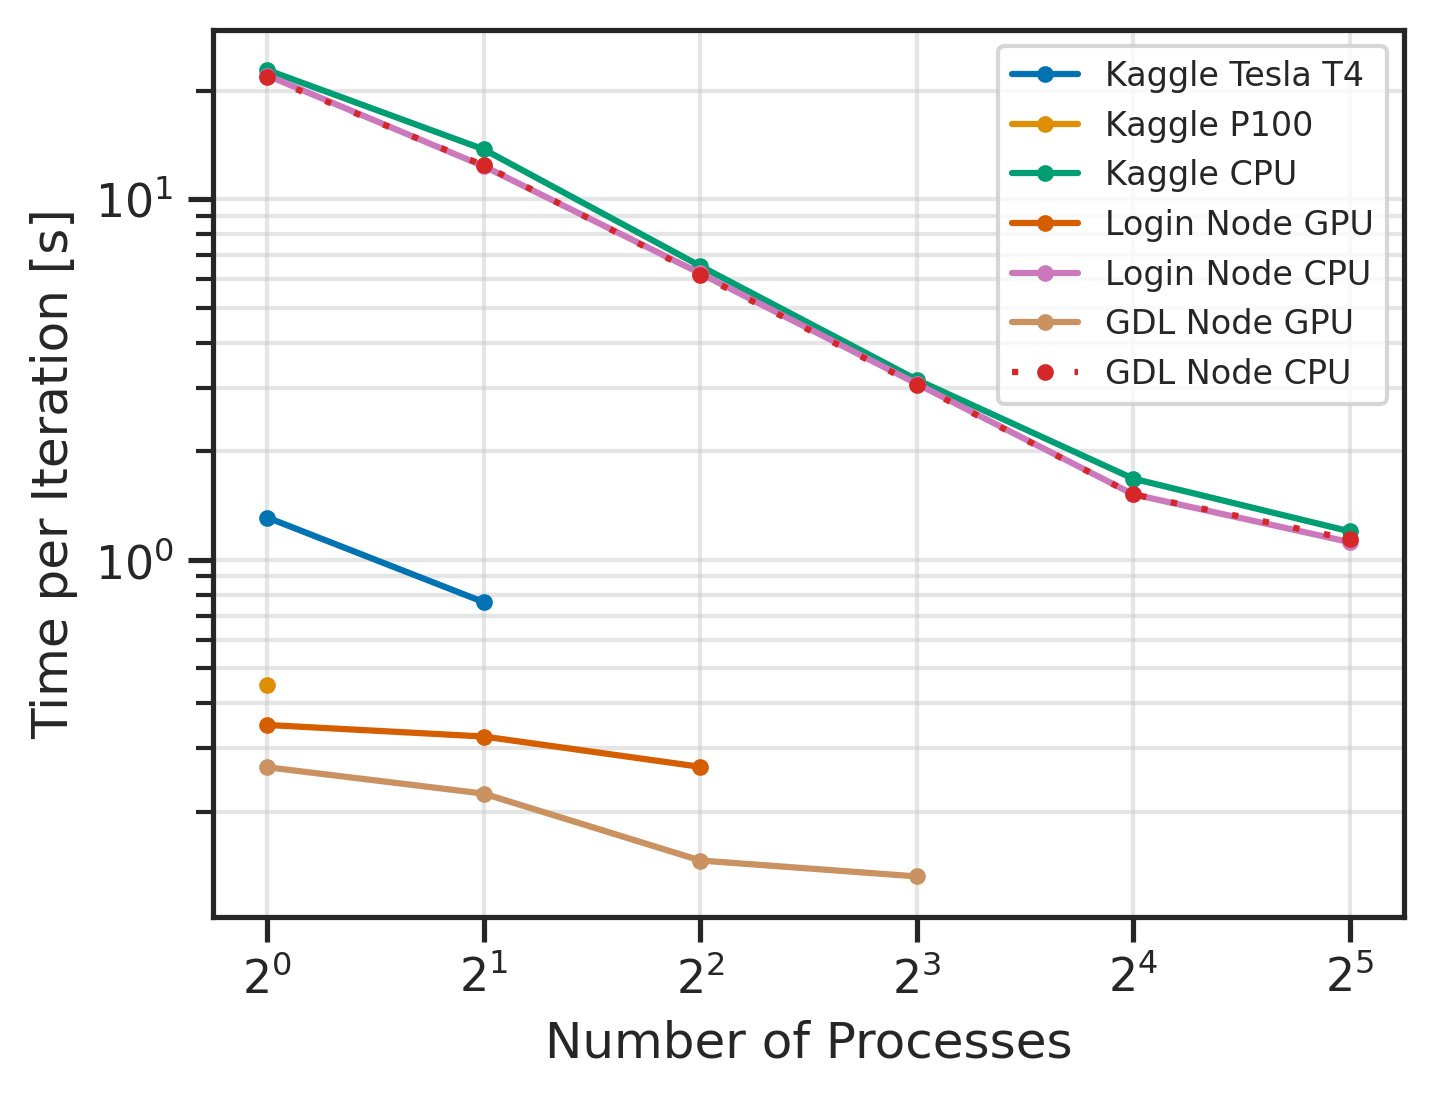

In [71]:
sns.set_theme(style="ticks", context="notebook", palette="colorblind")

plt.figure(figsize=(6.4 * 0.8, 4.8 * 0.8), dpi=300)

plt.plot(
    [2**x for x in range(len(s_it_kaggle_tesla_t4))],
    s_it_kaggle_tesla_t4,
    marker=".",
    label=rf"Kaggle Tesla T4",
    color="C0",
)

plt.plot(
    [2**x for x in range(len(s_it_kaggle_p100))],
    s_it_kaggle_p100,
    marker=".",
    label=rf"Kaggle P100",
    color="C1",
)

plt.plot(
    [2**x for x in range(len(s_it_kaggle_tpu))],
    s_it_kaggle_tpu,
    marker=".",
    label=rf"Kaggle CPU",
    color="C2",
)

plt.plot(
    [2**x for x in range(len(s_it_login_node_v100))],
    s_it_login_node_v100,
    marker=".",
    label=rf"Login Node GPU",
    color="C3",
)

plt.plot(
    [2**x for x in range(len(s_it_login_node_cpu))],
    s_it_login_node_cpu,
    marker=".",
    label=rf"Login Node CPU",
    color="C4",
)

plt.plot(
    [2**x for x in range(len(s_it_gdl_v100))],
    s_it_gdl_v100,
    marker=".",
    label=rf"GDL Node GPU",
    color="C5",
)

plt.plot(
    [2**x for x in range(len(s_it_gdl_cpu))],
    s_it_gdl_cpu,
    marker=".",
    label=rf"GDL Node CPU",
    linestyle=(0, (1, 4)),
    color="tab:red",
)

plt.xscale("log", base=2)
plt.yscale("log")

plt.xlabel(rf"Number of Processes")
plt.ylabel("Time per Iteration [s]")

plt.grid(which="both", alpha=0.5)
plt.legend(loc="upper right", fontsize=8)
plt.show()

# Speedup:


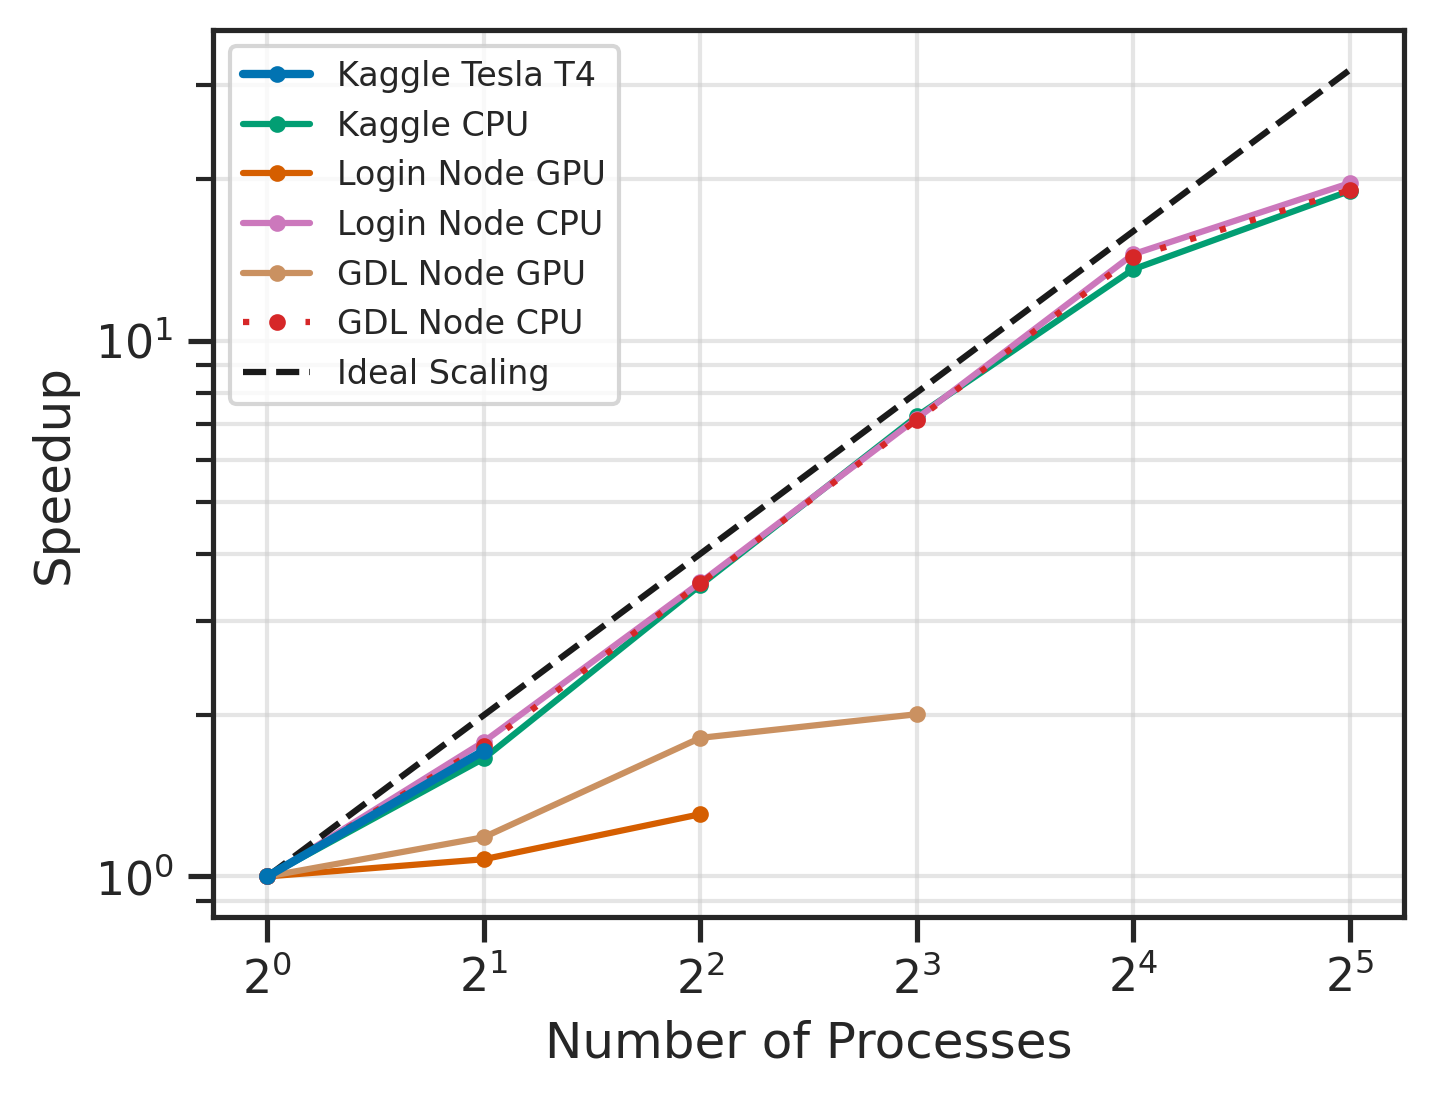

In [72]:
def calculate_speedup(s_it_data):
    """
    Calculate speedup from time per iteration data.
    Speedup = T_sequential / T_parallel = T_1_process / T_n_processes
    """
    if len(s_it_data) == 0:
        return []

    # Use the first value (1 process) as baseline
    baseline_time = s_it_data[0]

    # Calculate speedup for each number of processes
    speedup = [baseline_time / time for time in s_it_data]

    return speedup


sns.set_theme(style="ticks", context="notebook", palette="colorblind")

plt.figure(figsize=(6.4 * 0.8, 4.8 * 0.8), dpi=300)

plt.plot(
    [2**x for x in range(len(s_it_kaggle_tesla_t4))],
    calculate_speedup(s_it_kaggle_tesla_t4),
    marker=".",
    label=rf"Kaggle Tesla T4",
    color="C0",
    zorder=100,
    linewidth=2,
)
"""
plt.plot(
    [2**x for x in range(len(s_it_kaggle_p100))],
    calculate_speedup(s_it_kaggle_p100),
    marker='.',
    label=rf"Kaggle P100",
    color="C1",
)
"""
plt.plot(
    [2**x for x in range(len(s_it_kaggle_tpu))],
    calculate_speedup(s_it_kaggle_tpu),
    marker=".",
    label=rf"Kaggle CPU",
    color="C2",
)

plt.plot(
    [2**x for x in range(len(s_it_login_node_v100))],
    calculate_speedup(s_it_login_node_v100),
    marker=".",
    label=rf"Login Node GPU",
    color="C3",
)

plt.plot(
    [2**x for x in range(len(s_it_login_node_cpu))],
    calculate_speedup(s_it_login_node_cpu),
    marker=".",
    label=rf"Login Node CPU",
    color="C4",
)

plt.plot(
    [2**x for x in range(len(s_it_gdl_v100))],
    calculate_speedup(s_it_gdl_v100),
    marker=".",
    label=rf"GDL Node GPU",
    color="C5",
)

plt.plot(
    [2**x for x in range(len(s_it_gdl_cpu))],
    calculate_speedup(s_it_gdl_cpu),
    marker=".",
    label=rf"GDL Node CPU",
    linestyle=(0, (1, 4)),
    color="tab:red",
)

plt.plot(
    [2**x for x in range(len(s_it_gdl_cpu))],
    [2**x for x in range(len(s_it_gdl_cpu))],
    "k--",
    label=rf"Ideal Scaling",
)

plt.xscale("log", base=2)
plt.yscale("log")

plt.xlabel(rf"Number of Processes")
plt.ylabel("Speedup")

plt.grid(which="both", alpha=0.5)
plt.legend(fontsize=8)
plt.show()

# Parallel Efficiency:


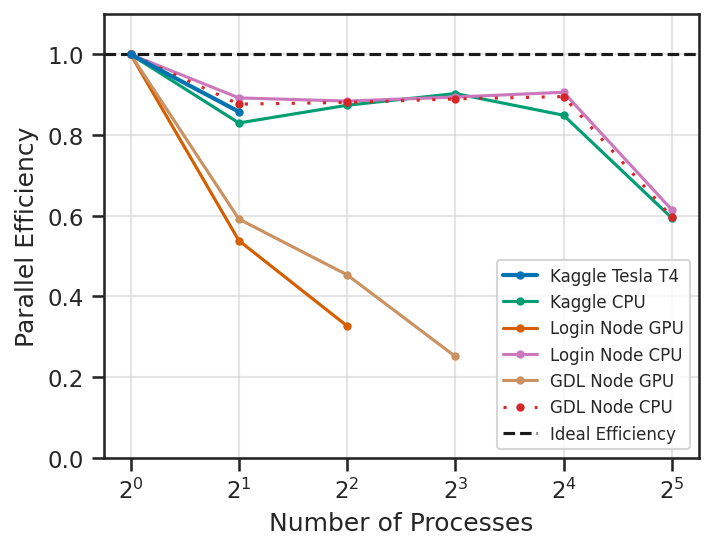

In [66]:
def calculate_parallel_efficiency(s_it_data):
    """
    Calculate parallel efficiency from time per iteration data.
    Efficiency = Speedup / Number_of_Processes
    """
    if len(s_it_data) == 0:
        return []

    # Use the first value (1 process) as baseline
    baseline_time = s_it_data[0]

    # Calculate speedup for each number of processes
    speedup = [baseline_time / time for time in s_it_data]
    
    # Calculate efficiency = speedup / number_of_processes
    efficiency = [speedup[i] / (2**i) for i in range(len(speedup))]

    return efficiency


sns.set_theme(style="ticks", context="notebook", palette="colorblind")

plt.figure(figsize=(6.4 * 0.8, 4.8 * 0.8), dpi=150)

plt.plot(
    [2**x for x in range(len(s_it_kaggle_tesla_t4))],
    calculate_parallel_efficiency(s_it_kaggle_tesla_t4),
    marker=".",
    label=rf"Kaggle Tesla T4",
    color="C0",
    zorder=100,
    linewidth=2,
)

plt.plot(
    [2**x for x in range(len(s_it_kaggle_tpu))],
    calculate_parallel_efficiency(s_it_kaggle_tpu),
    marker=".",
    label=rf"Kaggle CPU",
    color="C2",
)

plt.plot(
    [2**x for x in range(len(s_it_login_node_v100))],
    calculate_parallel_efficiency(s_it_login_node_v100),
    marker=".",
    label=rf"Login Node GPU",
    color="C3",
)

plt.plot(
    [2**x for x in range(len(s_it_login_node_cpu))],
    calculate_parallel_efficiency(s_it_login_node_cpu),
    marker=".",
    label=rf"Login Node CPU",
    color="C4",
)

plt.plot(
    [2**x for x in range(len(s_it_gdl_v100))],
    calculate_parallel_efficiency(s_it_gdl_v100),
    marker=".",
    label=rf"GDL Node GPU",
    color="C5",
)

plt.plot(
    [2**x for x in range(len(s_it_gdl_cpu))],
    calculate_parallel_efficiency(s_it_gdl_cpu),
    marker=".",
    label=rf"GDL Node CPU",
    linestyle=(0, (1, 4)),
    color="tab:red",
)

# Ideal efficiency is always 1.0 (100%)
plt.axhline(y=1.0, color='k', linestyle='--', label='Ideal Efficiency')

plt.xscale("log", base=2)
plt.ylim(0, 1.1)  # Efficiency ranges from 0 to 1 (0% to 100%)

plt.xlabel(rf"Number of Processes")
plt.ylabel("Parallel Efficiency")

plt.grid(which="both", alpha=0.5)
plt.legend(fontsize=8)
plt.show()